# 实验六：生成式人工智能基础实验

代码目标：使用 MNIST 手写数字数据集训练 DCGAN 风格 GAN，观察 Generator 和 Discriminator 的对抗训练过程，并保存 Loss 曲线、判别器分数曲线和生成图片效果。

In [2]:
# 导入库、设置随机种子、设置参数
import gzip
import json
import random
import struct
import sys
import time
import warnings
from argparse import Namespace
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset, Subset
from IPython.display import Image, display

warnings.filterwarnings("ignore")

if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8", line_buffering=True)
if hasattr(sys.stderr, "reconfigure"):
    sys.stderr.reconfigure(encoding="utf-8", line_buffering=True)

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

RANDOM_SEED = 42
BATCH_SIZE = 64
NUM_EPOCHS = 50
LEARNING_RATE = 0.0002
LATENT_DIM = 100
SAMPLE_EVERY = 5
NUM_WORKERS = 0
FIXED_SAMPLE_COUNT = 64

cwd = Path.cwd()
if (cwd / "MNIST").exists() and cwd.name == "实验六":
    SCRIPT_DIR = cwd
elif (cwd / "实验六" / "MNIST").exists():
    SCRIPT_DIR = cwd / "实验六"
else:
    SCRIPT_DIR = Path(".").resolve()

MNIST_DIR = SCRIPT_DIR / "MNIST"
OUTPUT_DIR = SCRIPT_DIR / "outputs_exp6"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 快速测试时可改成：EPOCHS = 1; TRAIN_LIMIT = 512; SAMPLE_EVERY_NOTEBOOK = 1
EPOCHS = NUM_EPOCHS
BATCH_SIZE_NOTEBOOK = BATCH_SIZE
LEARNING_RATE_NOTEBOOK = LEARNING_RATE
LATENT_DIM_NOTEBOOK = LATENT_DIM
SAMPLE_EVERY_NOTEBOOK = SAMPLE_EVERY
TRAIN_LIMIT = None

LOCAL_MNIST_FILES = {
    "train_images": "train-images-idx3-ubyte.gz",
    "train_labels": "train-labels-idx1-ubyte.gz",
    "test_images": "t10k-images-idx3-ubyte.gz",
    "test_labels": "t10k-labels-idx1-ubyte.gz",
}

def print_header(title: str) -> None:
    print(f"========== {title} ==========")

def set_seed(seed: int = RANDOM_SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

def get_device() -> torch.device:
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

set_seed(RANDOM_SEED)
device = get_device()

print_header("Notebook 参数")
print(f"脚本目录：{SCRIPT_DIR}")
print(f"输出目录：{OUTPUT_DIR}")
print(f"当前设备：{device}")
print(f"Epoch：{EPOCHS}")
print(f"Batch Size：{BATCH_SIZE_NOTEBOOK}")
print(f"学习率：{LEARNING_RATE_NOTEBOOK}")
print(f"噪声维度：{LATENT_DIM_NOTEBOOK}")

========== Notebook 参数 ==========
脚本目录：C:\Users\qintian\Desktop\人工智能\实验六
输出目录：C:\Users\qintian\Desktop\人工智能\实验六\outputs_exp6
当前设备：cuda
Epoch：50
Batch Size：64
学习率：0.0002
噪声维度：100


========== 读取数据 ==========
数据来源：使用实验六/MNIST 本地 gzip 文件。
数据来源：本地数据：C:\Users\qintian\Desktop\人工智能\实验六\MNIST
训练集图像形状：(60000, 1, 28, 28)
实际训练样本数：60000
像素范围：[-1.0, 1.0]


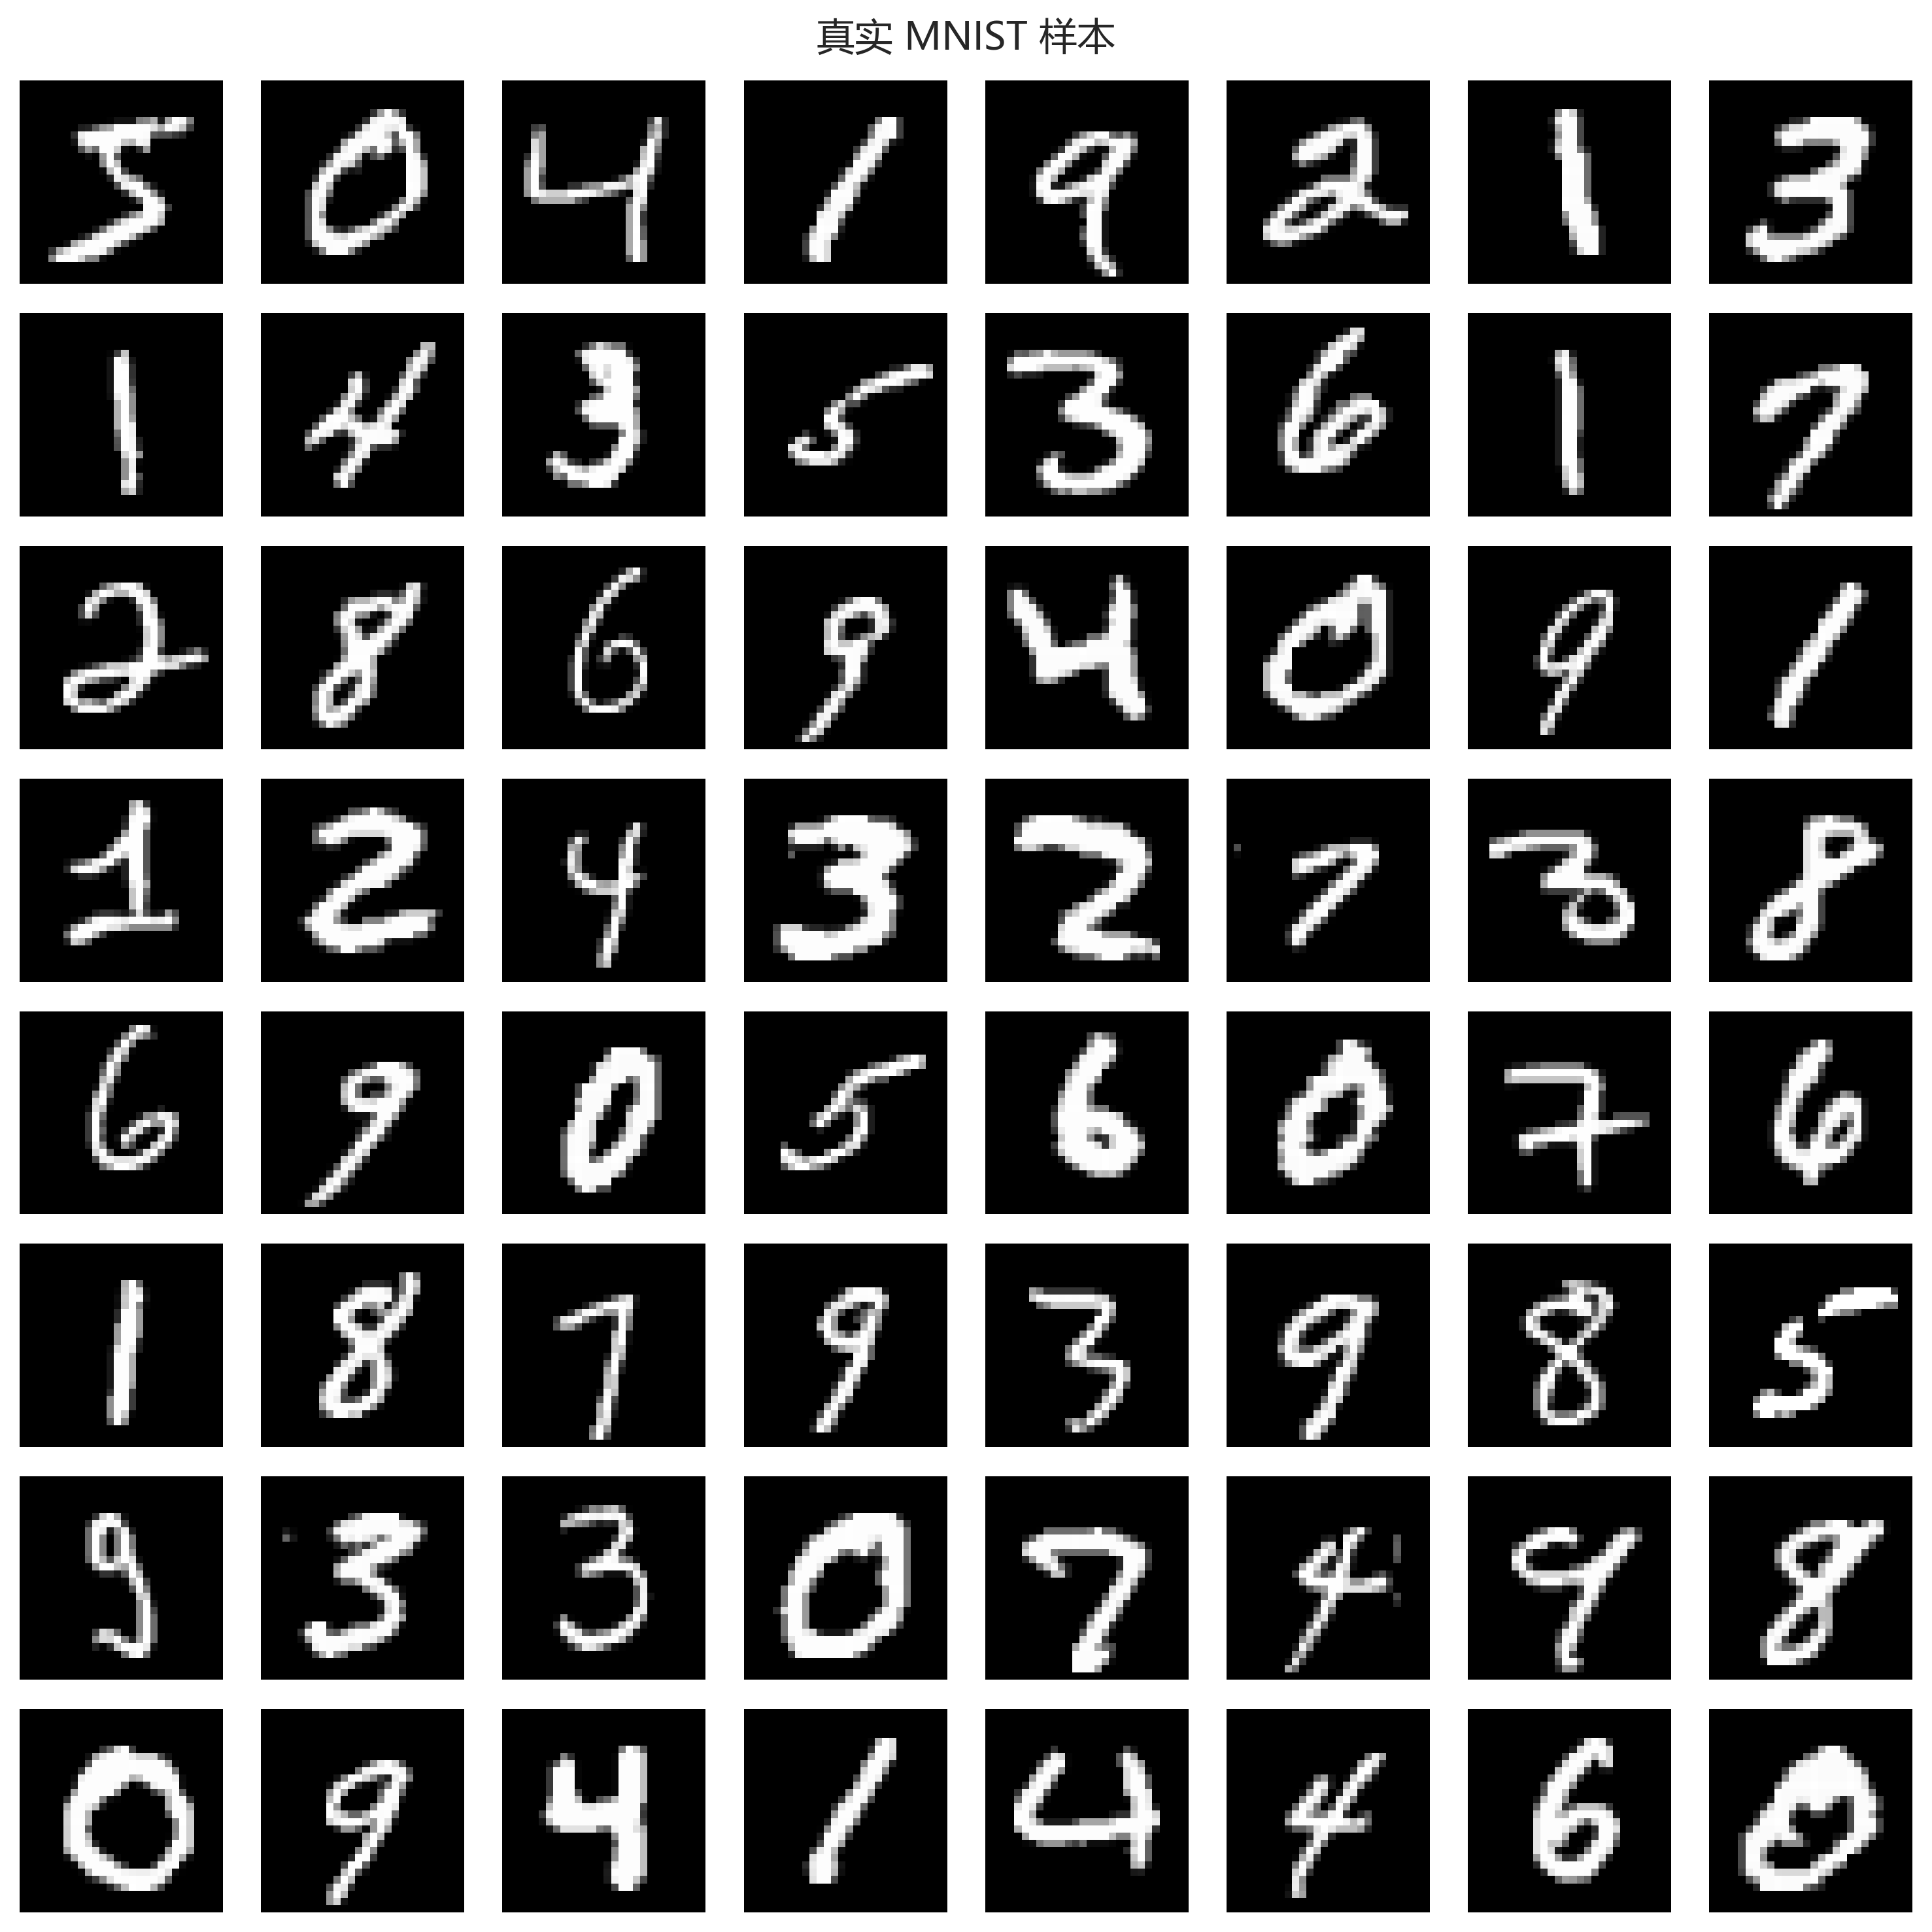

In [3]:
# 读取本地 MNIST 数据并可视化真实样本
def read_idx_images(path: Path) -> np.ndarray:
    with gzip.open(path, "rb") as file:
        magic, num_images, rows, cols = struct.unpack(">IIII", file.read(16))
        if magic != 2051:
            raise ValueError(f"{path} 不是合法的 IDX 图像文件，magic={magic}")
        data = np.frombuffer(file.read(), dtype=np.uint8)
    return data.reshape(num_images, rows, cols)

def read_idx_labels(path: Path) -> np.ndarray:
    with gzip.open(path, "rb") as file:
        magic, num_labels = struct.unpack(">II", file.read(8))
        if magic != 2049:
            raise ValueError(f"{path} 不是合法的 IDX 标签文件，magic={magic}")
        labels = np.frombuffer(file.read(), dtype=np.uint8)
    if len(labels) != num_labels:
        raise ValueError(f"{path} 标签数量不一致，文件头={num_labels}，实际={len(labels)}")
    return labels.astype(np.int64)

def normalize_mnist_images(images: np.ndarray) -> np.ndarray:
    images = images.astype(np.float32) / 127.5 - 1.0
    return images[:, None, :, :]

def load_local_mnist(mnist_dir: Path) -> Dict[str, np.ndarray]:
    required_paths = {key: mnist_dir / name for key, name in LOCAL_MNIST_FILES.items()}
    missing = [str(path) for path in required_paths.values() if not path.exists()]
    if missing:
        raise FileNotFoundError("本地 MNIST 文件不完整：" + "；".join(missing))

    train_images = read_idx_images(required_paths["train_images"])
    train_labels = read_idx_labels(required_paths["train_labels"])
    test_images = read_idx_images(required_paths["test_images"])
    test_labels = read_idx_labels(required_paths["test_labels"])

    return {
        "train_images": normalize_mnist_images(train_images),
        "train_labels": train_labels,
        "test_images": normalize_mnist_images(test_images),
        "test_labels": test_labels,
        "source": np.array([f"本地数据：{mnist_dir}"]),
    }

def load_torchvision_mnist() -> Dict[str, np.ndarray]:
    try:
        from torchvision import datasets
    except ImportError as exc:
        raise ImportError("本地 MNIST 不存在，且未安装 torchvision，无法自动下载 MNIST。") from exc

    data_root = SCRIPT_DIR / "mnist_torchvision_cache"
    train_dataset = datasets.MNIST(root=str(data_root), train=True, download=True)
    test_dataset = datasets.MNIST(root=str(data_root), train=False, download=True)
    return {
        "train_images": normalize_mnist_images(train_dataset.data.numpy()),
        "train_labels": train_dataset.targets.numpy().astype(np.int64),
        "test_images": normalize_mnist_images(test_dataset.data.numpy()),
        "test_labels": test_dataset.targets.numpy().astype(np.int64),
        "source": np.array([f"torchvision 下载缓存：{data_root}"]),
    }

def resolve_mnist_data(mnist_dir: Path = MNIST_DIR) -> Dict[str, np.ndarray]:
    try:
        data = load_local_mnist(mnist_dir)
        print("数据来源：使用实验六/MNIST 本地 gzip 文件。")
        return data
    except FileNotFoundError as exc:
        print(f"本地 MNIST 不完整，准备 fallback 到 torchvision：{exc}")
        data = load_torchvision_mnist()
        print("数据来源：使用 torchvision.datasets.MNIST(download=True)。")
        return data

class MNISTTensorDataset(Dataset):
    def __init__(self, images: np.ndarray, labels: np.ndarray) -> None:
        self.images = torch.from_numpy(images).float()
        self.labels = torch.from_numpy(labels).long()

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, index: int) -> Tuple[torch.Tensor, torch.Tensor]:
        return self.images[index], self.labels[index]

def make_loader(images: np.ndarray, labels: np.ndarray, batch_size: int = BATCH_SIZE, train_limit: Optional[int] = None) -> Tuple[DataLoader, Dataset]:
    dataset: Dataset = MNISTTensorDataset(images, labels)
    if train_limit is not None and train_limit > 0 and train_limit < len(dataset):
        generator = torch.Generator().manual_seed(RANDOM_SEED)
        indices = torch.randperm(len(dataset), generator=generator)[:train_limit].tolist()
        dataset = Subset(dataset, indices)
    if len(dataset) < 2:
        raise ValueError("训练样本数太少，至少需要 2 张图片。")
    drop_last = len(dataset) >= batch_size
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=drop_last, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
    return loader, dataset

def save_plot(path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.close()

def save_image_grid(images: torch.Tensor, output_path: Path, title: str, nrow: int = 8, max_images: int = 64) -> None:
    output_path.parent.mkdir(parents=True, exist_ok=True)
    images = images.detach().cpu()[:max_images]
    images = ((images + 1.0) / 2.0).clamp(0.0, 1.0)
    cols = min(nrow, len(images))
    rows = int(np.ceil(len(images) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.25, rows * 1.25))
    axes_array = np.array(axes).reshape(-1)
    for ax in axes_array:
        ax.axis("off")
    for ax, image in zip(axes_array, images):
        ax.imshow(image.squeeze(0).numpy(), cmap="gray", vmin=0, vmax=1)
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    save_plot(output_path)

print_header("读取数据")
data = resolve_mnist_data(MNIST_DIR)
train_images = data["train_images"]
train_labels = data["train_labels"]
data_source = str(data["source"][0])
train_loader, train_dataset = make_loader(train_images, train_labels, batch_size=BATCH_SIZE_NOTEBOOK, train_limit=TRAIN_LIMIT)

print(f"数据来源：{data_source}")
print(f"训练集图像形状：{train_images.shape}")
print(f"实际训练样本数：{len(train_dataset)}")
print(f"像素范围：[{train_images.min():.1f}, {train_images.max():.1f}]")

real_sample_count = min(FIXED_SAMPLE_COUNT, len(train_images))
real_samples = torch.from_numpy(train_images[:real_sample_count]).float()
real_path = OUTPUT_DIR / "exp6_real_samples.png"
save_image_grid(real_samples, real_path, title="真实 MNIST 样本")
display(Image(filename=str(real_path)))

In [5]:
# 定义 Generator 和 Discriminator
class Generator(nn.Module):
    def __init__(self, latent_dim: int = LATENT_DIM) -> None:
        super().__init__()
        self.latent_dim = latent_dim
        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 128 * 7 * 7),
            nn.BatchNorm1d(128 * 7 * 7),
            nn.ReLU(inplace=True),
        )
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 1, kernel_size=4, stride=2, padding=1),
            nn.Tanh(),
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        x = self.fc(z)
        x = x.view(z.size(0), 128, 7, 7)
        return self.deconv(x)

class Discriminator(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Flatten(),
        )
        self.classifier = nn.Linear(128 * 7 * 7, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # 返回 logit，并配合 BCEWithLogitsLoss 使用；等价于 Sigmoid + BCELoss，但数值更稳定。
        # torch.sigmoid(logit) 表示“输入图像是真实图片”的概率。
        return self.classifier(self.features(x))

def discriminator_probability(logits: torch.Tensor) -> torch.Tensor:
    return torch.sigmoid(logits)

print_header("模型构建")
generator = Generator(latent_dim=LATENT_DIM_NOTEBOOK).to(device)
discriminator = Discriminator().to(device)
print("生成器 Generator：")
print(generator)
print("判别器 Discriminator：")
print(discriminator)

========== 模型构建 ==========
生成器 Generator：
Generator(
  (fc): Sequential(
    (0): Linear(in_features=100, out_features=6272, bias=True)
    (1): BatchNorm1d(6272, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (deconv): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): Tanh()
  )
)
判别器 Discriminator：
Discriminator(
  (features): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Dropout(p=0.3, inplace=False)
    (3): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Dropout(p=0.3, inplace=False)
    (6): Flatten

In [6]:
# 定义训练函数和绘图函数
def generate_from_fixed_noise(generator: Generator, fixed_noise: torch.Tensor, device: torch.device) -> torch.Tensor:
    was_training = generator.training
    generator.eval()
    with torch.no_grad():
        generated = generator(fixed_noise.to(device)).cpu()
    generator.train(was_training)
    return generated

def plot_loss_curve(history: Sequence[Dict[str, float]], output_path: Path) -> None:
    epochs = [row["epoch"] for row in history]
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, [row["D_loss"] for row in history], marker="o", label="D_loss")
    plt.plot(epochs, [row["G_loss"] for row in history], marker="s", label="G_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("GAN 训练损失曲线")
    plt.legend()
    plt.grid(alpha=0.25)
    save_plot(output_path)

def plot_score_curve(history: Sequence[Dict[str, float]], output_path: Path) -> None:
    epochs = [row["epoch"] for row in history]
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, [row["D_x"] for row in history], marker="o", label="D(x)：真实图像判真概率")
    plt.plot(epochs, [row["D_G_z"] for row in history], marker="s", label="D(G(z))：生成图像判真概率")
    plt.xlabel("Epoch")
    plt.ylabel("判别器平均输出概率")
    plt.title("判别器分数变化曲线")
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(alpha=0.25)
    save_plot(output_path)

def save_generation_progress(saved_samples: Dict[int, torch.Tensor], output_path: Path, preferred_epochs: Sequence[int] = (1, 10, 20, 30, 40, 50)) -> None:
    if not saved_samples:
        return
    available_epochs = sorted(saved_samples)
    chosen_epochs = [epoch for epoch in preferred_epochs if epoch in saved_samples]
    for epoch in available_epochs:
        if epoch not in chosen_epochs:
            chosen_epochs.append(epoch)
        if len(chosen_epochs) >= min(6, len(available_epochs)):
            break
    chosen_epochs = sorted(chosen_epochs[:6])
    cols = 8
    rows = len(chosen_epochs)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.15, rows * 1.35))
    axes = np.array(axes).reshape(rows, cols)
    for row_idx, epoch in enumerate(chosen_epochs):
        images = ((saved_samples[epoch][:cols] + 1.0) / 2.0).clamp(0.0, 1.0)
        for col_idx in range(cols):
            ax = axes[row_idx, col_idx]
            ax.axis("off")
            ax.imshow(images[col_idx].squeeze(0).numpy(), cmap="gray", vmin=0, vmax=1)
            if col_idx == 0:
                ax.set_title(f"Epoch {epoch}", fontsize=10)
    fig.suptitle("固定噪声生成效果对比", fontsize=14)
    plt.tight_layout()
    save_plot(output_path)

def save_latent_interpolation(generator: Generator, latent_dim: int, device: torch.device, output_path: Path, steps: int = 10) -> None:
    generator.eval()
    z_start = torch.randn(1, latent_dim, device=device)
    z_end = torch.randn(1, latent_dim, device=device)
    ratios = torch.linspace(0, 1, steps, device=device).view(steps, 1)
    z = z_start * (1 - ratios) + z_end * ratios
    with torch.no_grad():
        images = generator(z).cpu()
    save_image_grid(images, output_path, title="潜在空间线性插值", nrow=steps, max_images=steps)

def train_gan(train_loader: DataLoader, generator: Generator, discriminator: Discriminator, device: torch.device, epochs: int, latent_dim: int, lr: float, sample_every: int, output_dir: Path) -> Tuple[List[Dict[str, float]], Dict[int, torch.Tensor], torch.Tensor]:
    criterion = nn.BCEWithLogitsLoss()
    optimizer_d = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))
    optimizer_g = torch.optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
    fixed_noise = torch.randn(FIXED_SAMPLE_COUNT, latent_dim, device=device)
    history: List[Dict[str, float]] = []
    saved_samples: Dict[int, torch.Tensor] = {}
    print_header("开始训练 GAN")
    for epoch in range(1, epochs + 1):
        start_time = time.time()
        totals = {"D_loss": 0.0, "G_loss": 0.0, "D_loss_real": 0.0, "D_loss_fake": 0.0, "D_x": 0.0, "D_G_z": 0.0}
        sample_count = 0
        generator.train()
        discriminator.train()
        for real_images, _ in train_loader:
            real_images = real_images.to(device, non_blocking=True)
            batch_size = real_images.size(0)
            real_targets = torch.ones(batch_size, 1, device=device)
            fake_targets = torch.zeros(batch_size, 1, device=device)
            optimizer_d.zero_grad()
            real_logits = discriminator(real_images)
            d_loss_real = criterion(real_logits, real_targets)
            noise = torch.randn(batch_size, latent_dim, device=device)
            fake_images = generator(noise)
            fake_logits_for_d = discriminator(fake_images.detach())
            d_loss_fake = criterion(fake_logits_for_d, fake_targets)
            d_loss = d_loss_real + d_loss_fake
            d_loss.backward()
            optimizer_d.step()
            optimizer_g.zero_grad()
            noise = torch.randn(batch_size, latent_dim, device=device)
            fake_images = generator(noise)
            fake_logits_for_g = discriminator(fake_images)
            g_loss = criterion(fake_logits_for_g, real_targets)
            g_loss.backward()
            optimizer_g.step()
            with torch.no_grad():
                d_x = discriminator_probability(real_logits).mean().item()
                d_g_z = discriminator_probability(fake_logits_for_g).mean().item()
            totals["D_loss"] += d_loss.item() * batch_size
            totals["G_loss"] += g_loss.item() * batch_size
            totals["D_loss_real"] += d_loss_real.item() * batch_size
            totals["D_loss_fake"] += d_loss_fake.item() * batch_size
            totals["D_x"] += d_x * batch_size
            totals["D_G_z"] += d_g_z * batch_size
            sample_count += batch_size
        row = {key: value / sample_count for key, value in totals.items()}
        row["epoch"] = epoch
        row["seconds"] = time.time() - start_time
        history.append(row)
        print(f"第 {epoch:03d}/{epochs:03d} 轮 | D_loss={row['D_loss']:.4f} | G_loss={row['G_loss']:.4f} | D_loss_real={row['D_loss_real']:.4f} | D_loss_fake={row['D_loss_fake']:.4f} | D(x)={row['D_x']:.4f} | D(G(z))={row['D_G_z']:.4f} | 用时={row['seconds']:.2f}s")
        if epoch == 1 or (sample_every > 0 and epoch % sample_every == 0):
            generated = generate_from_fixed_noise(generator, fixed_noise, device)
            saved_samples[epoch] = generated
            save_image_grid(generated, output_dir / f"exp6_generated_epoch_{epoch:03d}.png", title=f"第 {epoch} 轮生成样本")
    final_samples = generate_from_fixed_noise(generator, fixed_noise, device)
    saved_samples[epochs] = final_samples
    save_image_grid(final_samples, output_dir / "exp6_generated_final.png", title="最终生成样本")
    return history, saved_samples, fixed_noise.detach().cpu()

def write_summary(output_path: Path, args: Namespace, data_source: str, device: torch.device, train_size: int, history: Sequence[Dict[str, float]]) -> None:
    final_row = history[-1]
    lines = [
        "实验六：MNIST GAN 训练摘要", "", f"数据来源：{data_source}", f"训练样本数：{train_size}", f"运行设备：{device}",
        f"随机种子：{RANDOM_SEED}", f"Epoch：{args.epochs}", f"Batch Size：{args.batch_size}", f"学习率：{args.lr}",
        f"噪声维度：{args.latent_dim}", f"采样间隔：{args.sample_every}", "", "最终一轮指标：",
        f"D_loss：{final_row['D_loss']:.6f}", f"G_loss：{final_row['G_loss']:.6f}", f"D_loss_real：{final_row['D_loss_real']:.6f}",
        f"D_loss_fake：{final_row['D_loss_fake']:.6f}", f"D(x)：{final_row['D_x']:.6f}", f"D(G(z))：{final_row['D_G_z']:.6f}",
    ]
    output_path.write_text("".join(lines) + "", encoding="utf-8")

print("训练函数和绘图函数已定义。")

训练函数和绘图函数已定义。


In [7]:
# 开始训练 GAN
history, saved_samples, fixed_noise = train_gan(
    train_loader=train_loader,
    generator=generator,
    discriminator=discriminator,
    device=device,
    epochs=EPOCHS,
    latent_dim=LATENT_DIM_NOTEBOOK,
    lr=LEARNING_RATE_NOTEBOOK,
    sample_every=SAMPLE_EVERY_NOTEBOOK,
    output_dir=OUTPUT_DIR,
)

========== 开始训练 GAN ==========
第 001/050 轮 | D_loss=0.9702 | G_loss=1.6935 | D_loss_real=0.4848 | D_loss_fake=0.4854 | D(x)=0.6578 | D(G(z))=0.3182 | 用时=5.23s
第 002/050 轮 | D_loss=1.0109 | G_loss=1.1647 | D_loss_real=0.5113 | D_loss_fake=0.4995 | D(x)=0.6338 | D(G(z))=0.3544 | 用时=4.72s
第 003/050 轮 | D_loss=1.0408 | G_loss=1.2376 | D_loss_real=0.5270 | D_loss_fake=0.5137 | D(x)=0.6416 | D(G(z))=0.3511 | 用时=4.90s
第 004/050 轮 | D_loss=1.1538 | G_loss=1.0655 | D_loss_real=0.5821 | D_loss_fake=0.5718 | D(x)=0.6019 | D(G(z))=0.3934 | 用时=4.65s
第 005/050 轮 | D_loss=1.1914 | G_loss=0.9980 | D_loss_real=0.5996 | D_loss_fake=0.5918 | D(x)=0.5854 | D(G(z))=0.4091 | 用时=5.51s
第 006/050 轮 | D_loss=1.1993 | G_loss=0.9777 | D_loss_real=0.6026 | D_loss_fake=0.5967 | D(x)=0.5809 | D(G(z))=0.4140 | 用时=7.47s
第 007/050 轮 | D_loss=1.1934 | G_loss=0.9872 | D_loss_real=0.5992 | D_loss_fake=0.5941 | D(x)=0.5822 | D(G(z))=0.4107 | 用时=10.72s
第 008/050 轮 | D_loss=1.1880 | G_loss=0.9986 | D_loss_real=0.5966 | D_los

In [8]:
# 绘制 Loss 曲线和判别器分数曲线
print_header("结果可视化与保存")
plot_loss_curve(history, OUTPUT_DIR / "exp6_loss_curve.png")
plot_score_curve(history, OUTPUT_DIR / "exp6_discriminator_score_curve.png")
save_generation_progress(saved_samples, OUTPUT_DIR / "exp6_generation_progress.png")
save_latent_interpolation(generator, latent_dim=LATENT_DIM_NOTEBOOK, device=device, output_path=OUTPUT_DIR / "exp6_latent_interpolation.png")

pd.DataFrame(history).to_csv(OUTPUT_DIR / "exp6_training_history.csv", index=False, encoding="utf-8-sig")
(OUTPUT_DIR / "exp6_training_history.json").write_text(json.dumps(history, ensure_ascii=False, indent=2), encoding="utf-8")
torch.save({"model_state_dict": generator.state_dict(), "latent_dim": LATENT_DIM_NOTEBOOK, "random_seed": RANDOM_SEED}, OUTPUT_DIR / "exp6_generator.pt")
torch.save({"model_state_dict": discriminator.state_dict(), "random_seed": RANDOM_SEED}, OUTPUT_DIR / "exp6_discriminator.pt")
notebook_args = Namespace(epochs=EPOCHS, batch_size=BATCH_SIZE_NOTEBOOK, lr=LEARNING_RATE_NOTEBOOK, latent_dim=LATENT_DIM_NOTEBOOK, sample_every=SAMPLE_EVERY_NOTEBOOK, train_limit=TRAIN_LIMIT)
write_summary(OUTPUT_DIR / "exp6_metrics_summary.txt", args=notebook_args, data_source=data_source, device=device, train_size=len(train_dataset), history=history)
print("曲线、历史记录和模型文件已保存。")

========== 结果可视化与保存 ==========
曲线、历史记录和模型文件已保存。


C:\Users\qintian\Desktop\人工智能\实验六\outputs_exp6\exp6_generated_final.png


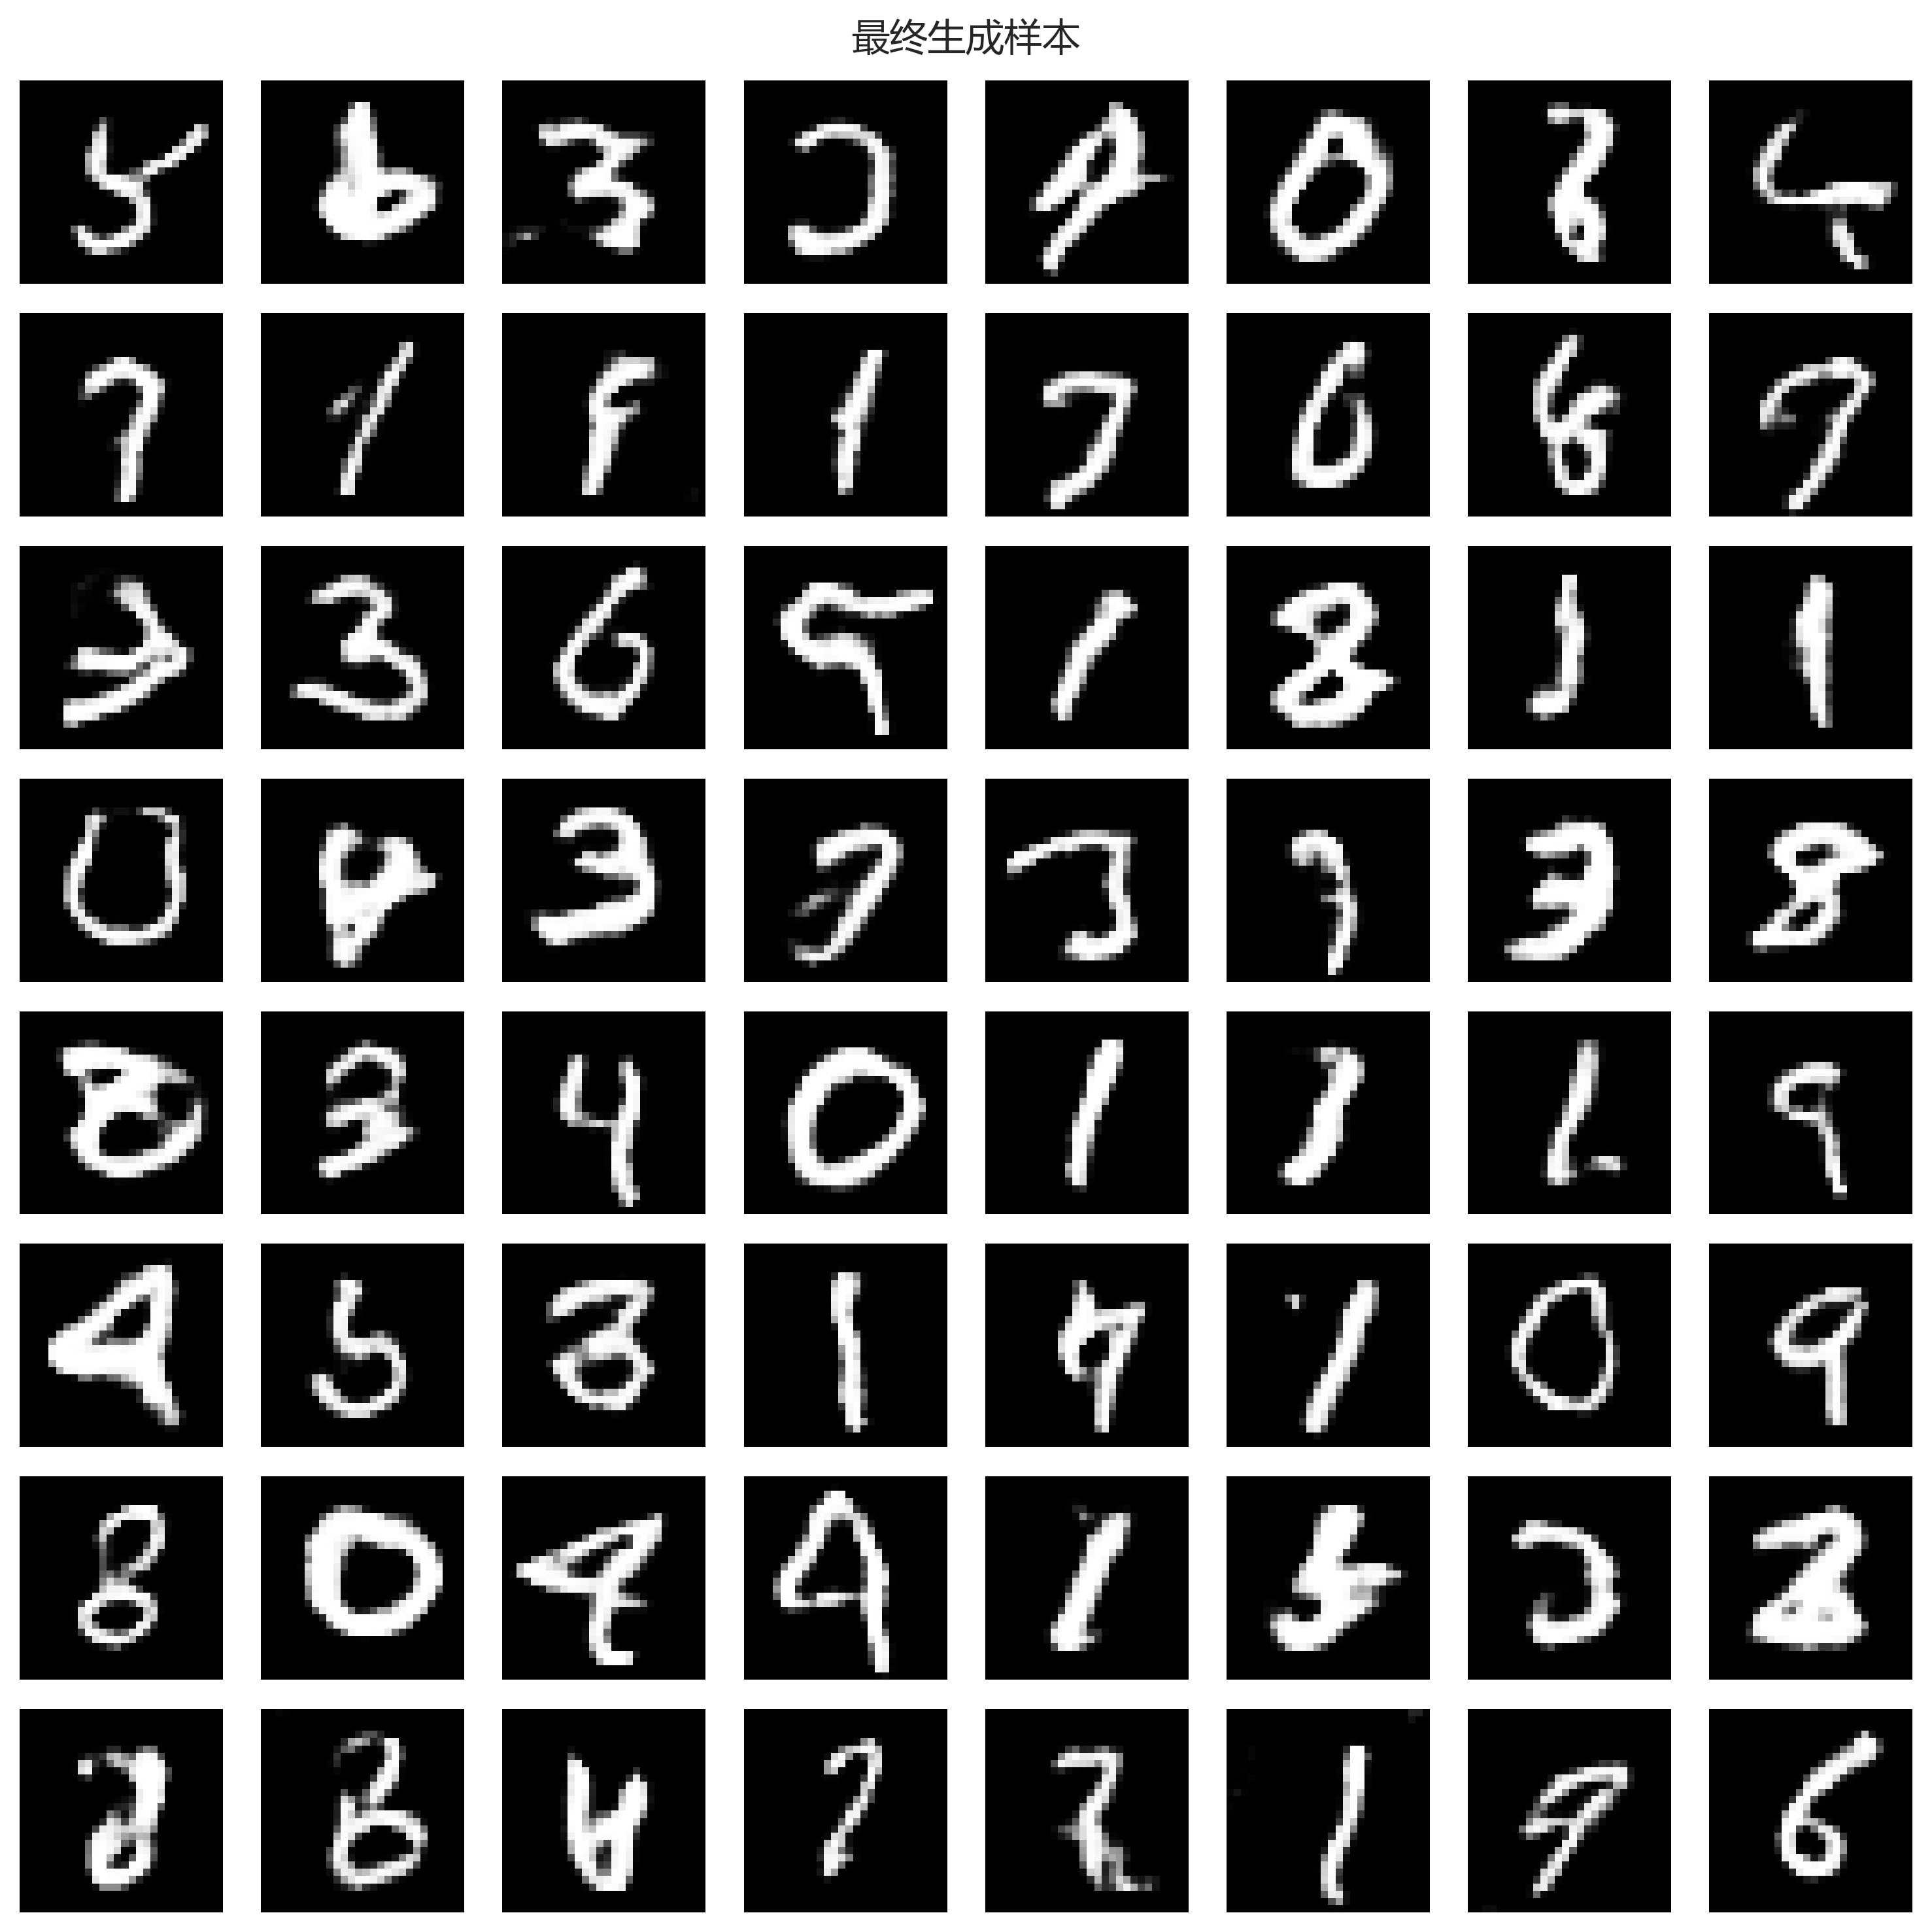

C:\Users\qintian\Desktop\人工智能\实验六\outputs_exp6\exp6_generation_progress.png


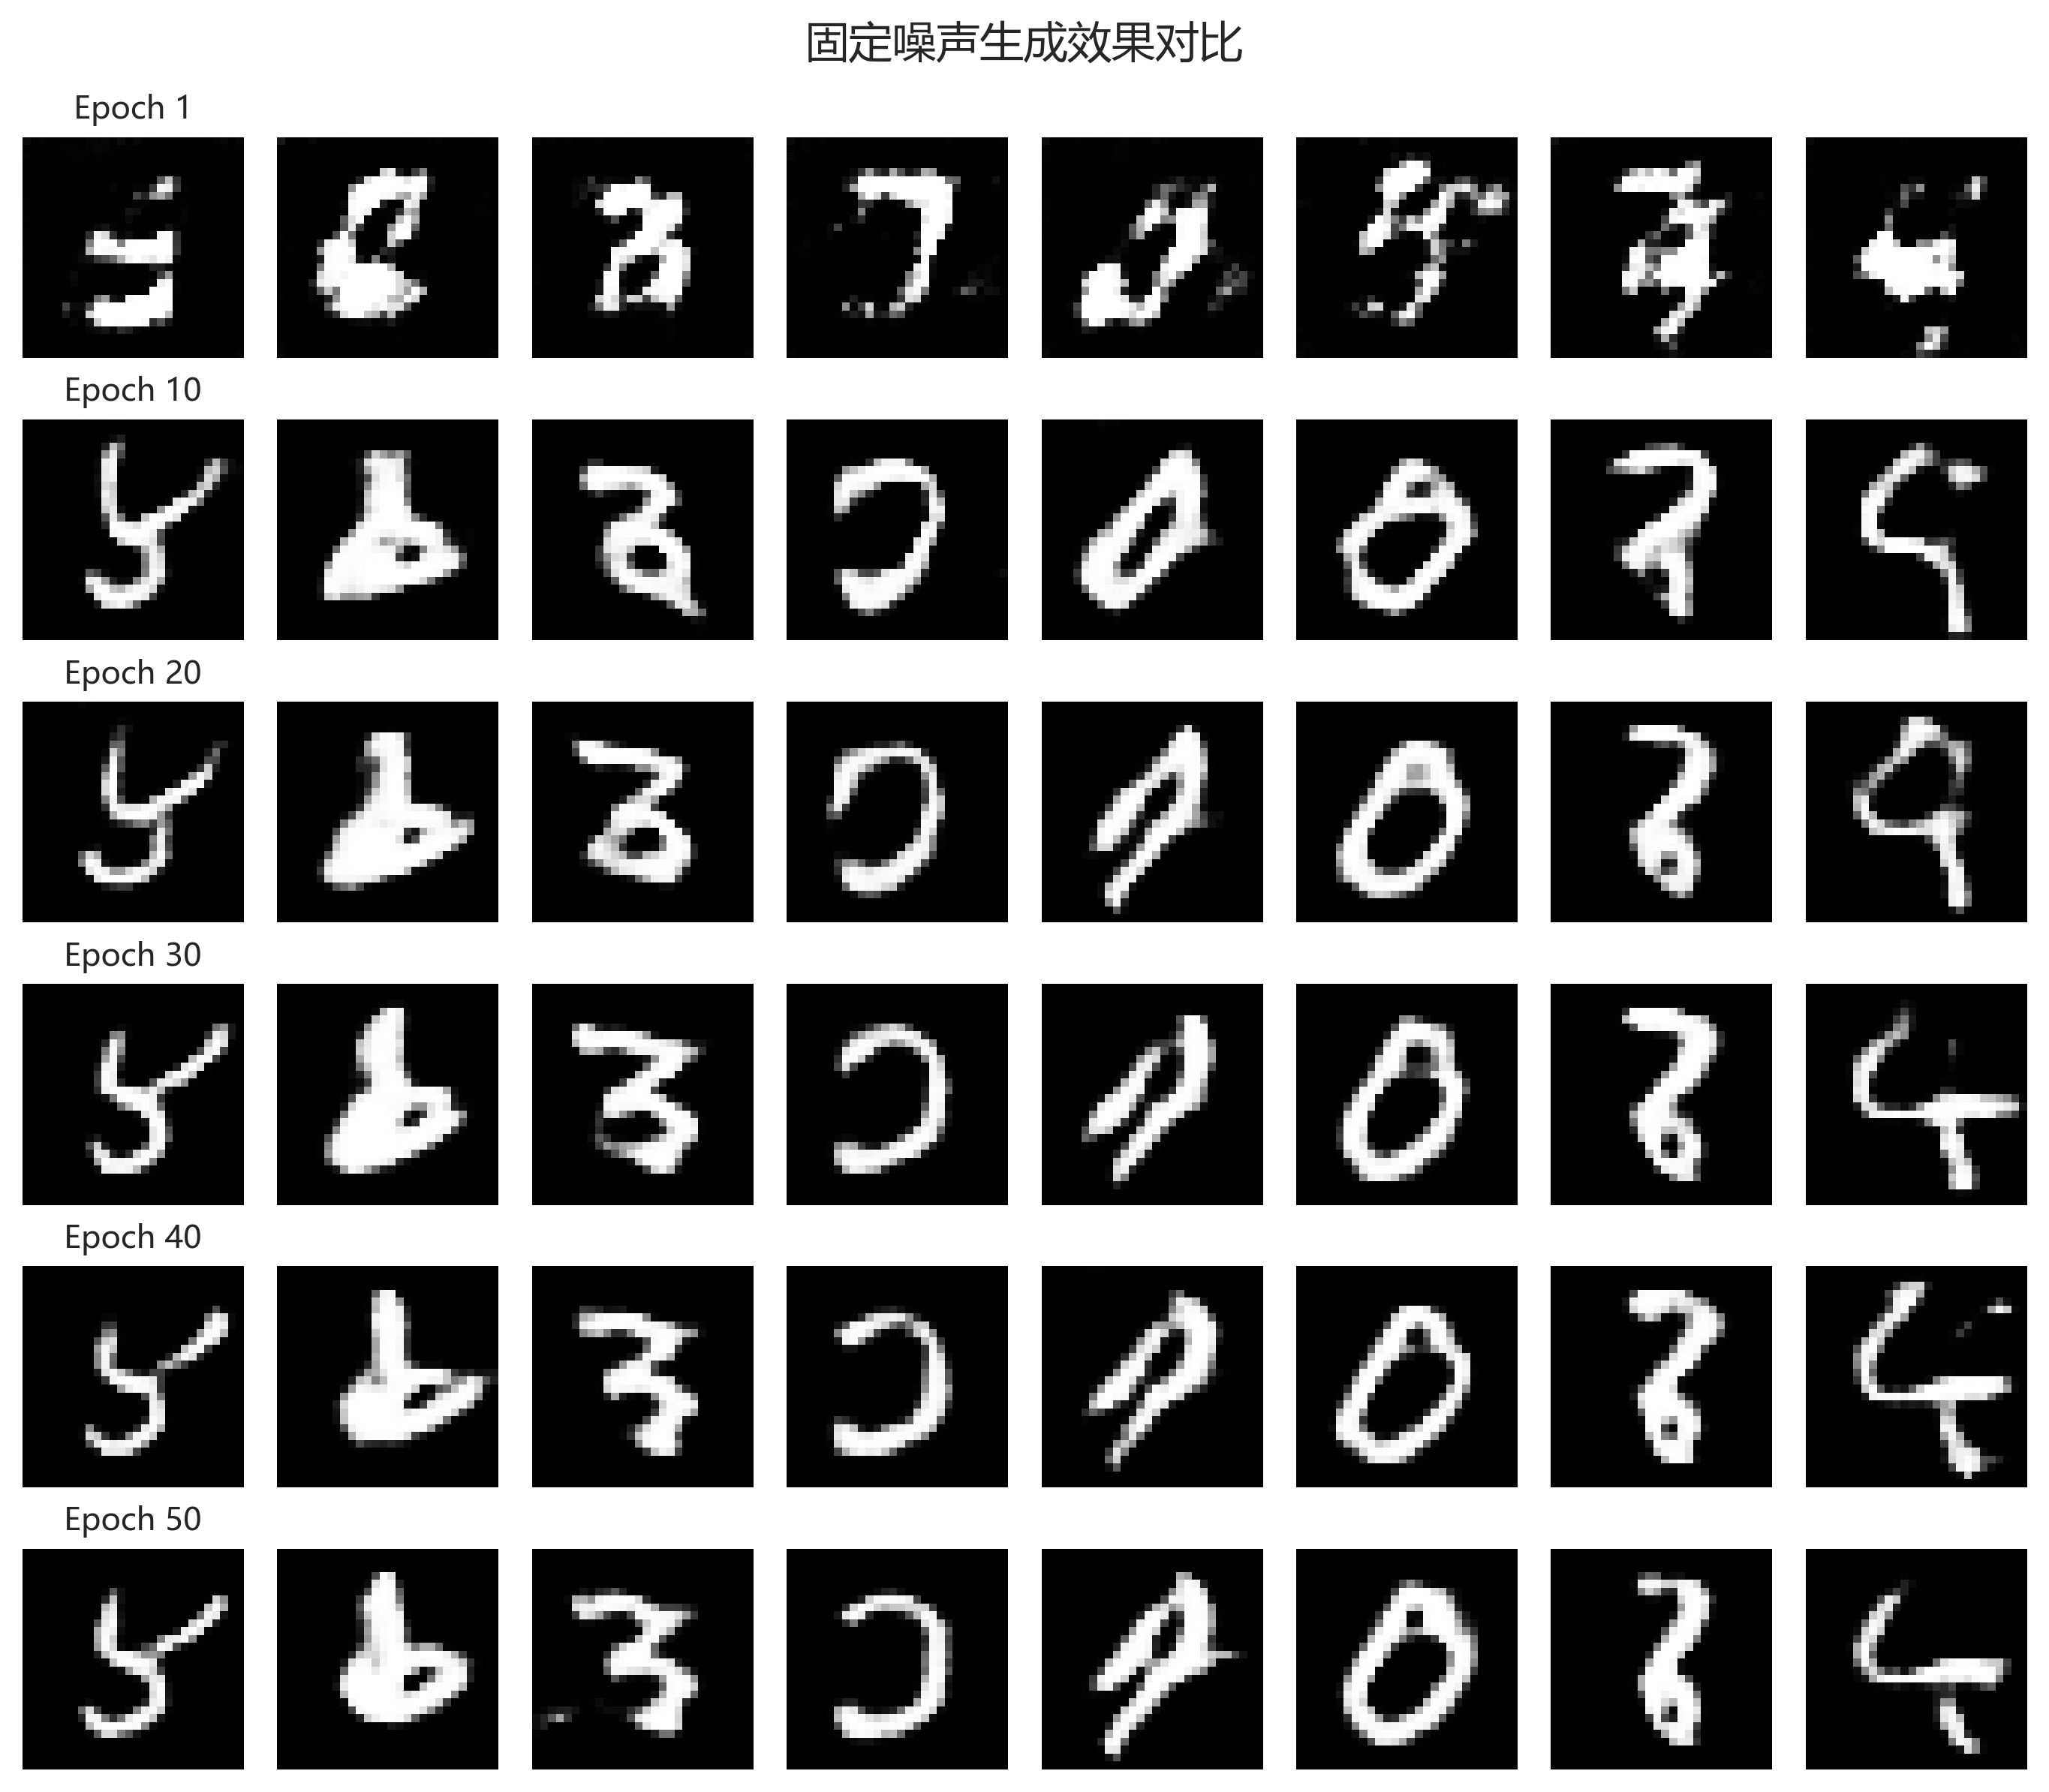

C:\Users\qintian\Desktop\人工智能\实验六\outputs_exp6\exp6_latent_interpolation.png


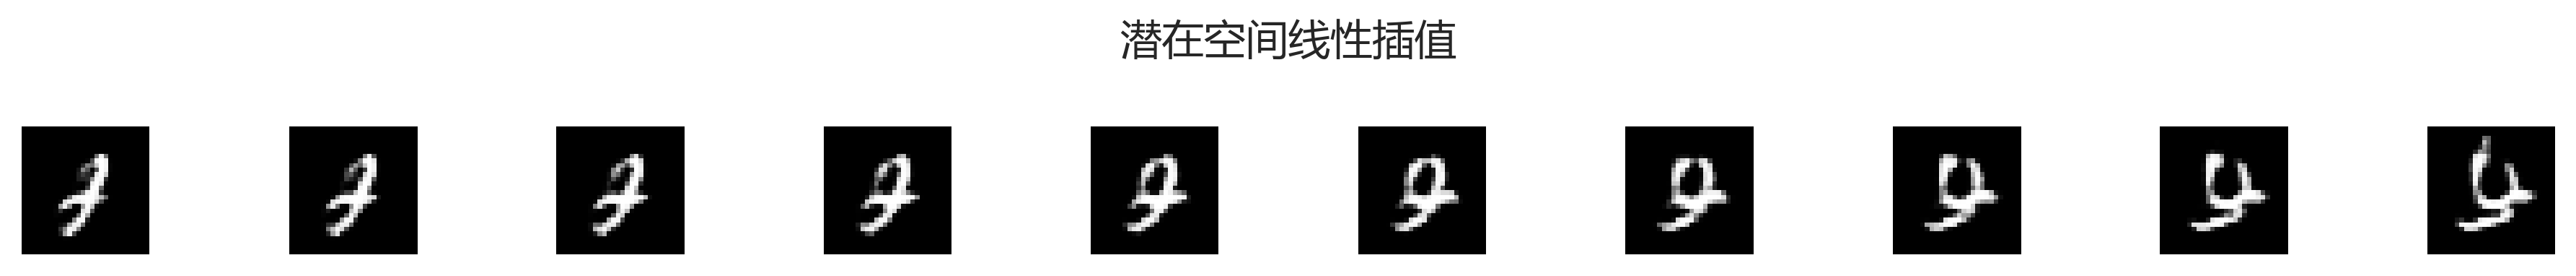

In [9]:
# 展示最终生成图、训练进度图、潜在空间插值图
image_files = ["exp6_generated_final.png", "exp6_generation_progress.png", "exp6_latent_interpolation.png"]
for name in image_files:
    path = OUTPUT_DIR / name
    print(path)
    if path.exists():
        display(Image(filename=str(path)))

In [10]:
# 打印输出文件列表
print_header("已保存文件列表")
for file_path in sorted(OUTPUT_DIR.glob("*")):
    if file_path.is_file():
        print(file_path)

========== 已保存文件列表 ==========
C:\Users\qintian\Desktop\人工智能\实验六\outputs_exp6\exp6_discriminator.pt
C:\Users\qintian\Desktop\人工智能\实验六\outputs_exp6\exp6_discriminator_score_curve.png
C:\Users\qintian\Desktop\人工智能\实验六\outputs_exp6\exp6_generated_epoch_001.png
C:\Users\qintian\Desktop\人工智能\实验六\outputs_exp6\exp6_generated_epoch_005.png
C:\Users\qintian\Desktop\人工智能\实验六\outputs_exp6\exp6_generated_epoch_010.png
C:\Users\qintian\Desktop\人工智能\实验六\outputs_exp6\exp6_generated_epoch_015.png
C:\Users\qintian\Desktop\人工智能\实验六\outputs_exp6\exp6_generated_epoch_020.png
C:\Users\qintian\Desktop\人工智能\实验六\outputs_exp6\exp6_generated_epoch_025.png
C:\Users\qintian\Desktop\人工智能\实验六\outputs_exp6\exp6_generated_epoch_030.png
C:\Users\qintian\Desktop\人工智能\实验六\outputs_exp6\exp6_generated_epoch_035.png
C:\Users\qintian\Desktop\人工智能\实验六\outputs_exp6\exp6_generated_epoch_040.png
C:\Users\qintian\Desktop\人工智能\实验六\outputs_exp6\exp6_generated_epoch_045.png
C:\Users\qintian\Desktop\人工智能\实验六\outputs_exp6\exp6_generat